**FNN using DeepXDE module**

In [1]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
import torch

from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Data loading

In [2]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [3]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [4]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_i = PCA(n_components=0.9999, svd_solver='full')
pca_i.fit(data_i_train)

# Number of principal components
n_components_i = pca_i.n_components_
print(f"Number of principal components: {n_components_i}")

# Transform and inverse transform data_i_train
data_i_train_pca = pca_i.transform(data_i_train)
data_i_train_reconstructed = pca_i.inverse_transform(data_i_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_train - data_i_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca = pca_i.transform(data_i_test)
data_i_test_reconstructed = pca_i.inverse_transform(data_i_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_test - data_i_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 8
Mean Squared Error for data_i_train: 6.034478281655721e-06
Mean Squared Error for data_i_test: 6.047068209249223e-06


In [5]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_c = PCA(n_components=0.999999, svd_solver='full')
pca_c.fit(data_c_train)

# Number of principal components
n_components_c = pca_c.n_components_
print(f"Number of principal components: {n_components_c}")

# Transform and inverse transform data_i_train
data_c_train_pca = pca_c.transform(data_c_train)
data_c_train_reconstructed = pca_c.inverse_transform(data_c_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_c_train - data_c_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_train: {mse_train}")

# Transform and inverse transform data_i_test
data_c_test_pca = pca_c.transform(data_c_test)
data_c_test_reconstructed = pca_c.inverse_transform(data_c_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_c_test - data_c_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 14
Mean Squared Error for data_c_train: 4.681798798946135e-06
Mean Squared Error for data_c_test: 4.380550389501745e-06


In [6]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_h = PCA(n_components=0.9999, svd_solver='full')
pca_h.fit(data_h_train)

# Number of principal components
n_components_h = pca_h.n_components_
print(f"Number of principal components: {n_components_h}")

# Transform and inverse transform data_i_train
data_h_train_pca = pca_h.transform(data_h_train)
data_h_train_reconstructed = pca_h.inverse_transform(data_h_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_h_train - data_h_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_train: {mse_train}")

# Transform and inverse transform data_i_test
data_h_test_pca = pca_h.transform(data_h_test)
data_h_test_reconstructed = pca_h.inverse_transform(data_h_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_h_test - data_h_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 7
Mean Squared Error for data_h_train: 1.7271833105513615e-06
Mean Squared Error for data_c_test: 1.7335751758054943e-06


In [7]:
X_train = data_i_train_pca.astype(np.float32)
y_train_c = data_c_train_pca.astype(np.float32)

In [8]:
X_test = data_i_test_pca.astype(np.float32)
y_test_c = data_c_test_pca.astype(np.float32)

In [9]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [10]:
m = 601
dim_x = 1
net_c = dde.nn.fnn.FNN(
    [n_components_i, 400, 400, 400, n_components_c],
    "relu",
    "Glorot normal",
)

In [11]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [n_components_i, 400, 400, 400, n_components_c]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 330014


In [12]:
model_c = dde.Model(data_c, net_c)

In [13]:
model_c.compile("adam", lr=0.001, loss="mse", metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2-1000.pt'
model_c.restore(path)
# losshistory_c, train_state_c = model_c.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 1.809394 s



c:\Users\arnab\anaconda3\envs\deepxde\Lib\site-packages\deepxde\model.py:1096: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


In [14]:
# model_c.compile("adam", lr=0.0001, loss="mse", metrics=["l2 relative error"])
# losshistory_c, train_state_c = model_c.train(iterations=500, display_every=100)

In [15]:
y_train_h = data_h_train_pca.astype(np.float32)
y_test_h = data_h_test_pca.astype(np.float32)

In [16]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [17]:
m = 601
dim_x = 1
net_h = dde.nn.fnn.FNN(
    [n_components_i, 400, 400, 400, n_components_h],
    "relu",
    "Glorot normal",
)

In [18]:
model_h = dde.Model(data_h, net_h)

In [19]:
model_h.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2-1000.pt'
model_h.restore(path)
# losshistory_h, train_state_h = model_h.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 0.000559 s



In [20]:
# model_h.compile("adam", lr=0.0001, loss='mse', metrics=["l2 relative error"])
# losshistory_h, train_state_h = model_h.train(iterations=500, display_every=100)

0.004539835893996077 0.0020017757890454842


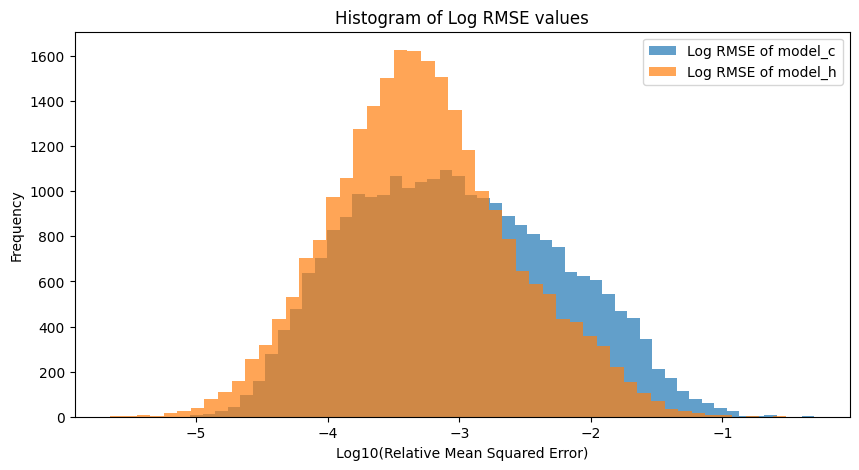

RMSE at c = 2: Mean = 0.012935080034018462, Std = 0.03846266730059571
RMSE at c = 3: Mean = 0.0194075684253171, Std = 0.07577532819296118
RMSE at c = 4: Mean = 0.02452363214517461, Std = 0.11797287763060449


In [21]:
# Use trained model to make predictions
predictions_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca))  # Ensure model_c is defined
predictions_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.sum((predictions_c - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1)  # Averaging across time points
rmse_h = np.sum((predictions_h - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1)  # Averaging across time points

print(np.mean(rmse_c), np.mean(rmse_h))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 3, 4]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


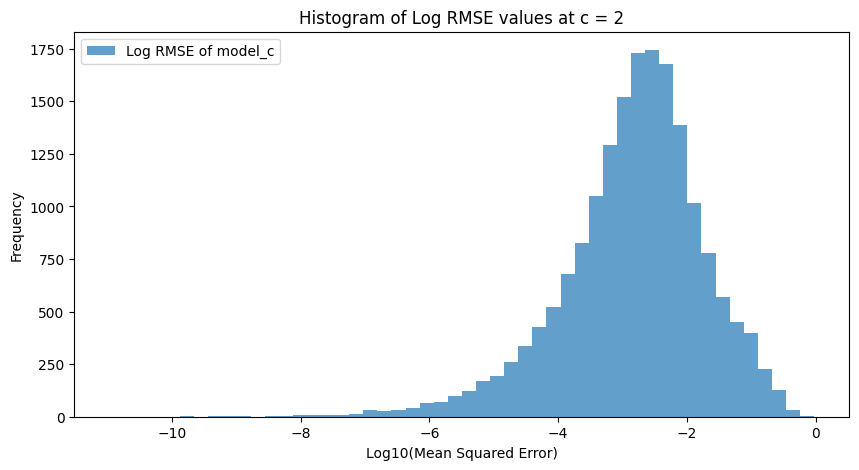

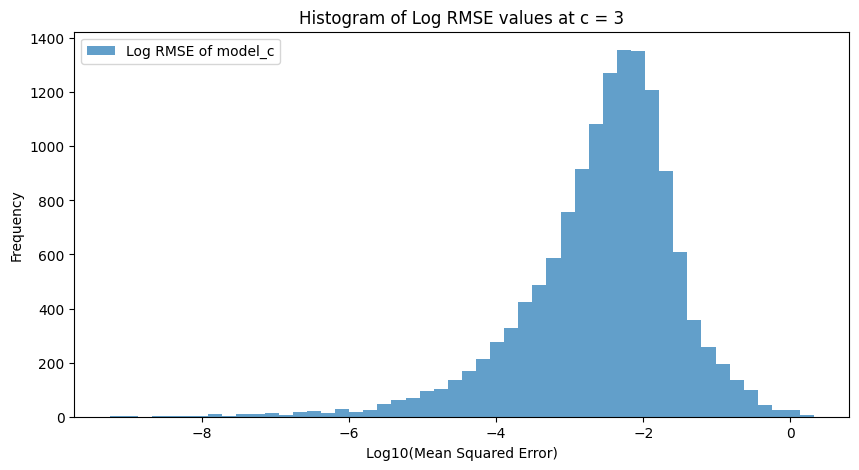

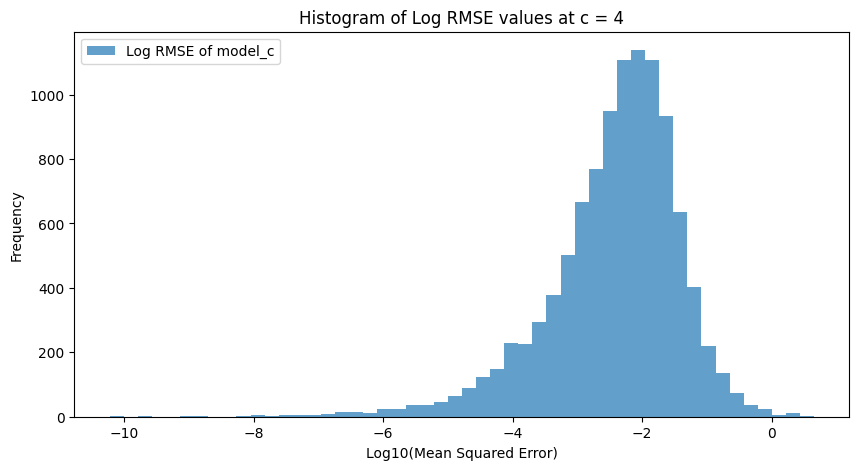

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["4"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 4')
plt.legend()
plt.show()

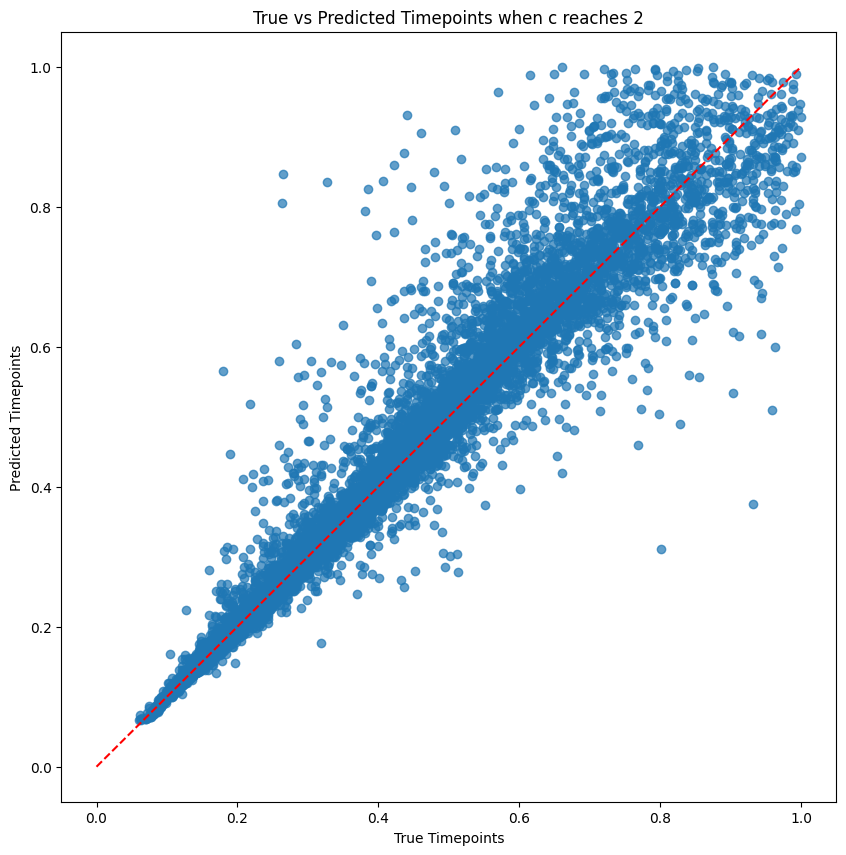

In [23]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2)[0]
    pred_indices = np.where(predictions_c[i] >= 2)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2')
plt.show()

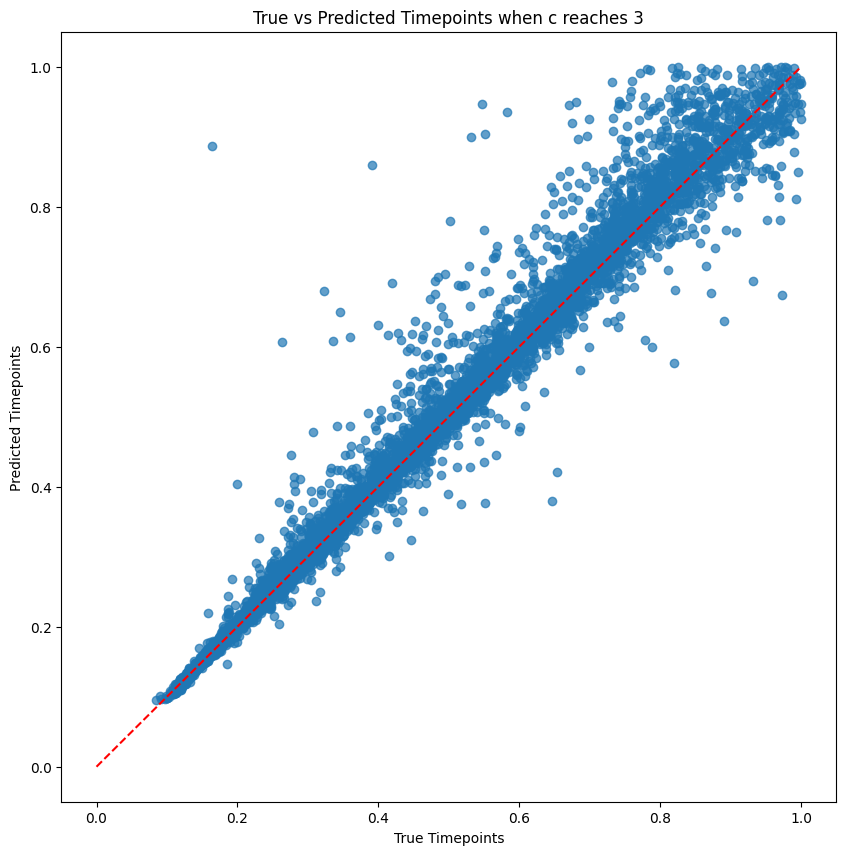

In [24]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 3)[0]
    pred_indices = np.where(predictions_c[i] >= 3)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 3')
plt.show()

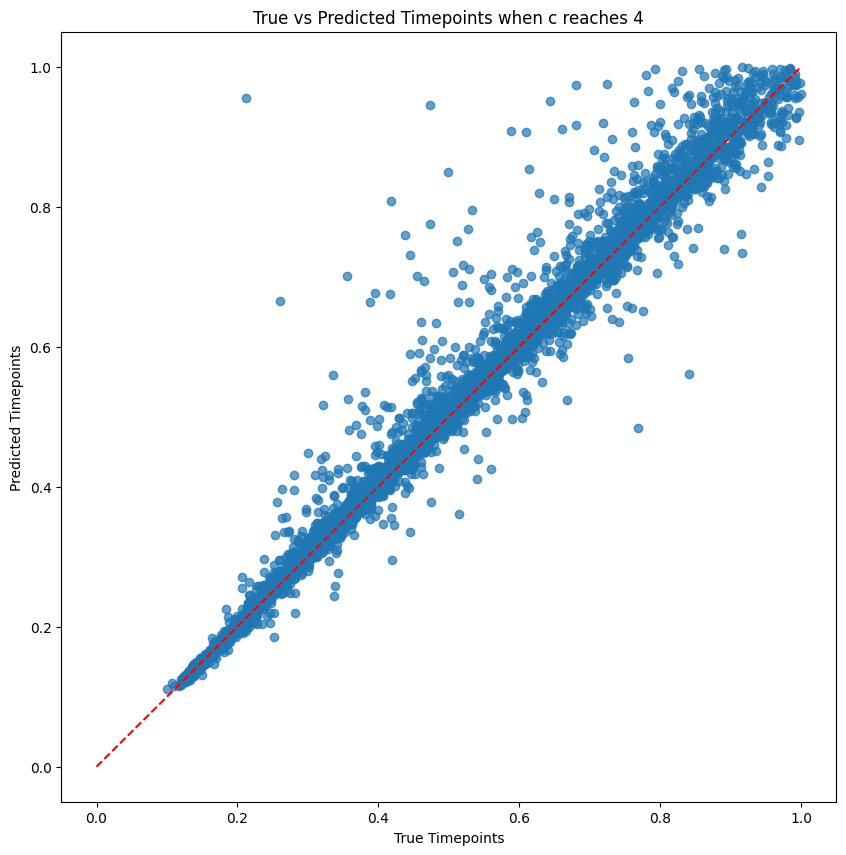

In [25]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 4)[0]
    pred_indices = np.where(predictions_c[i] >= 4)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 10))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 4')
plt.show()

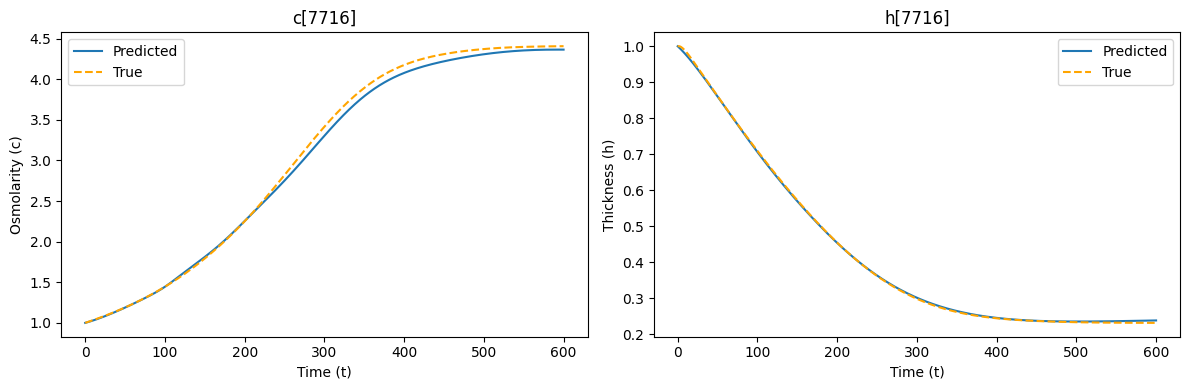

True PCA coefficients for c: [ 4.48031459 -6.57795881 -1.27125838  1.99460436 -0.47546216 -0.11148609
 -0.20728925  0.07375654 -0.08941847  0.06824613  0.00856201  0.05025694
  0.02244237  0.02723124]
Predicted PCA coefficients for c: [[ 3.0573874  -6.3016777  -0.60653424  1.7635025  -0.54628253 -0.11591026
  -0.25808161 -0.0225947  -0.0794861   0.15697601 -0.02432645  0.06978105
   0.00989882  0.02633875]]
True PCA coefficients for h: [ 0.83478978  2.33445263  0.20450753 -0.33936528  0.14895389 -0.06727859
 -0.01686904]
Predicted PCA coefficients for h: [[ 8.5092765e-01  2.2774661e+00  2.1238355e-01 -3.4652740e-01
   1.3156056e-01 -9.5082439e-02 -1.9052529e-03]]


In [26]:
n = np.random.choice(len(data_i_test_pca))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c = model_c.predict(data_i_test_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))

true_pca_h = data_h_test_pca[n]
pred_pca_h = model_h.predict(data_i_test_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

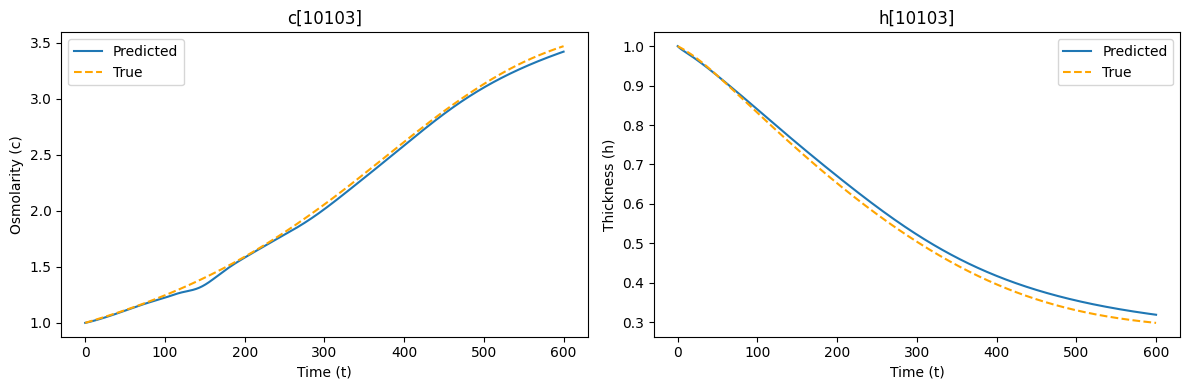

True PCA coefficients for c: [-2.10474345e+01 -4.82814326e+00  2.39516549e+00 -7.38798531e-01
  2.37146739e-01  1.17033198e-02 -2.45944260e-02  5.70542632e-02
 -1.46421594e-02  3.80017370e-02  6.59125295e-03  2.94716127e-02
  1.13999169e-02  2.34190562e-02]
Predicted PCA coefficients for c: [[-2.1787292e+01 -4.8711972e+00  2.2091317e+00 -8.8490951e-01
   7.9500973e-02 -1.7167374e-01 -7.6897986e-02  4.1304104e-02
   3.4798060e-02  2.9120475e-02  2.0999718e-02  2.7300041e-02
   3.6951721e-02 -2.6295559e-02]]
True PCA coefficients for h: [ 4.31431825  2.09245369 -0.5834159   0.09926506 -0.05135248 -0.05150988
  0.02560111]
Predicted PCA coefficients for h: [[ 4.730142    1.9212638  -0.5741225   0.06769893 -0.03526078 -0.05258464
   0.01252674]]


In [27]:
n = np.random.choice(len(data_i_test_pca))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c = model_c.predict(data_i_test_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))

true_pca_h = data_h_test_pca[n]
pred_pca_h = model_h.predict(data_i_test_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

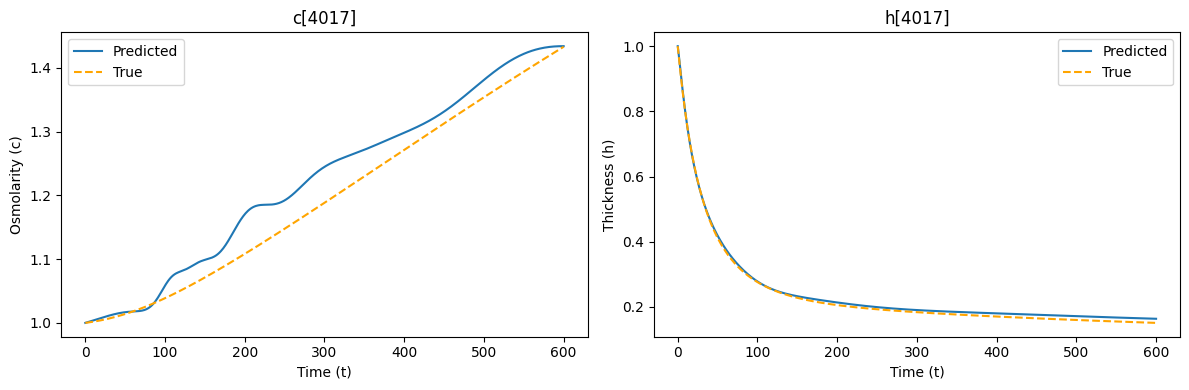

True PCA coefficients for c: [-4.78077666e+01  3.87462619e+00 -1.12357611e+00 -1.20610939e-02
 -3.67842261e-01  1.65500843e-01  2.54277835e-01 -1.80983065e-01
  1.35475169e-01 -5.11596483e-02 -4.31599545e-02 -2.34457154e-02
 -2.26170479e-02 -1.14642152e-02]
Predicted PCA coefficients for c: [[-4.7057289e+01  4.1925025e+00 -1.2097442e+00 -5.0526485e-02
  -3.1363595e-01  1.5648368e-01  2.4791849e-01 -2.1488285e-01
   2.5284508e-01  3.5951614e-02 -4.5476448e-02 -1.0457832e-02
  -3.9319240e-02  6.4217463e-02]]
True PCA coefficients for h: [-3.78837577 -1.00633613  0.12081739  0.41998899  0.27121701  0.08566353
 -0.02041284]
Predicted PCA coefficients for h: [[-3.5999417  -1.0719063   0.16270386  0.40000546  0.27509782  0.06721359
  -0.02630672]]


In [28]:
n = np.random.choice(len(data_i_test_pca))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c = model_c.predict(data_i_test_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))

true_pca_h = data_h_test_pca[n]
pred_pca_h = model_h.predict(data_i_test_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

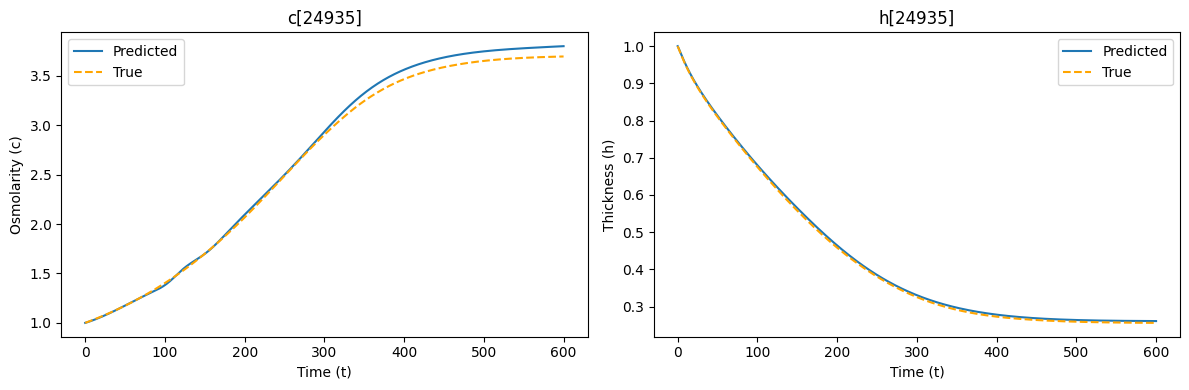

True PCA coefficients for c: [-7.56561251 -3.20477193 -0.87079189  1.35465427 -0.33727307 -0.21459215
 -0.12284488  0.11265915 -0.08256016  0.06087449  0.01949048  0.04509944
  0.02370941  0.02604963]
Predicted PCA coefficients for c: [[-6.1340923  -3.8482356  -0.76421344  1.445092   -0.53154445 -0.20035926
  -0.18374115 -0.02765513 -0.08188888  0.14293635  0.07499415  0.06742875
   0.03029485 -0.01265873]]
True PCA coefficients for h: [ 1.01839814e+00  1.67310757e+00  1.31126715e-01 -2.50765971e-01
  1.32552047e-01 -5.70880041e-02  1.20509333e-03]
Predicted PCA coefficients for h: [[ 1.1399142   1.6682835   0.1277872  -0.2566384   0.13791095 -0.05163341
  -0.00518453]]


In [29]:
n = np.random.choice(len(data_i_test_pca))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c = model_c.predict(data_i_test_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))

true_pca_h = data_h_test_pca[n]
pred_pca_h = model_h.predict(data_i_test_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

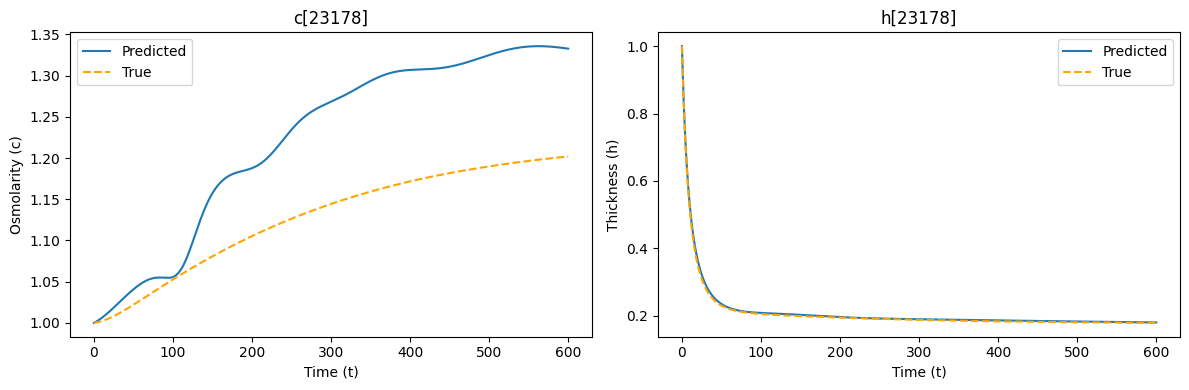

True PCA coefficients for c: [-4.98707606e+01  5.20793487e+00 -1.56006090e+00  2.69634595e-01
 -4.56894698e-01  6.37819204e-02  2.60542915e-01 -1.26773494e-01
  1.33998390e-01 -2.93930708e-02 -4.48112675e-02 -1.41824310e-02
 -2.32174677e-02 -8.09001608e-03]
Predicted PCA coefficients for c: [[-4.7244854e+01  5.0794644e+00 -1.5788841e+00  2.7150702e-01
  -5.0491905e-01  1.9346085e-01  2.7479863e-01 -3.9801605e-02
   4.9147520e-02  1.1277914e-02 -4.5269441e-02  4.4558328e-02
  -3.2817110e-02  6.2891673e-03]]
True PCA coefficients for h: [-4.28894314 -2.64325081 -0.70638425 -0.09911439  0.03486344  0.04249291
  0.02128917]
Predicted PCA coefficients for h: [[-4.222584   -2.6056697  -0.6679063  -0.07866222  0.05449097  0.05801149
   0.00871549]]


In [30]:
n = np.random.choice(len(data_i_test_pca))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c = model_c.predict(data_i_test_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(model_c.predict(data_i_test_pca[n].reshape(1, -1)))

true_pca_h = data_h_test_pca[n]
pred_pca_h = model_h.predict(data_i_test_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(model_h.predict(data_i_test_pca[n].reshape(1, -1)))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

In [31]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca2"
# model_c.save(path)

In [32]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca2"
# model_h.save(path)

In [33]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_center.jld2", 'r')

data_I_glob = np.array(np.array(datastore_glob["data_I_center"]))

data_c_glob = np.array(np.array(datastore_glob["data_c_center"]))
data_h_glob = np.array(np.array(datastore_glob["data_h_center"]))


Global RMSE for model_c: 0.03949703792679919
Global RMSE for model_h: 0.059420535019490024


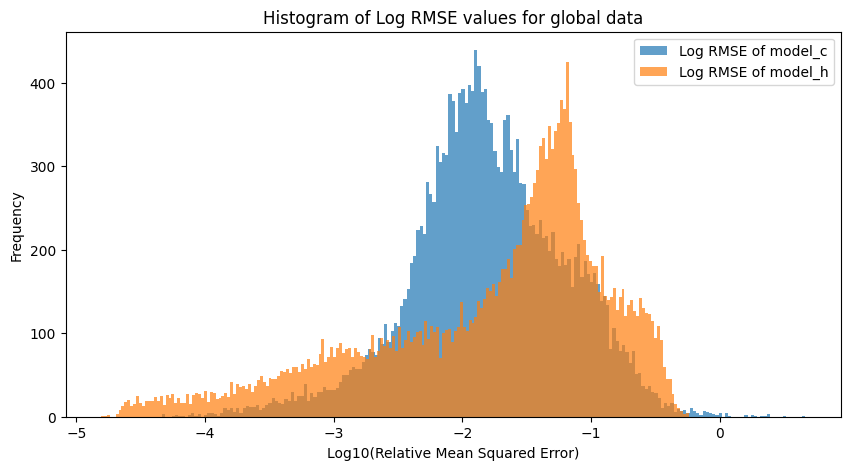

RMSE at c = 2: Mean = 0.6140293779054978, Std = 0.5256692152576009
RMSE at c = 3: Mean = 0.7114178950151199, Std = 0.9091382619224373
RMSE at c = 4: Mean = 0.7432908215627183, Std = 0.9849408268365776


In [34]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

X_test_glob_pca = pca_i.transform(X_test_glob)
y_test_c_glob_pca = pca_c.transform(y_test_c_glob)
y_test_h_glob_pca = pca_h.transform(y_test_h_glob)

# Use trained models to make predictions
predictions_c_glob_pca = model_c.predict(X_test_glob_pca)
predictions_h_glob_pca = model_h.predict(X_test_glob_pca)

predictions_c_glob = pca_c.inverse_transform(predictions_c_glob_pca)
predictions_h_glob = pca_h.inverse_transform(predictions_h_glob_pca)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.mean((predictions_c_glob - y_test_c_glob) ** 2, axis=1) / np.mean((y_test_c_glob ** 2), axis=1)
rmse_h_glob = np.mean((predictions_h_glob - y_test_h_glob) ** 2, axis=1) / np.mean((y_test_h_glob ** 2), axis=1)

print("Global RMSE for model_c:", np.mean(rmse_c_glob))
print("Global RMSE for model_h:", np.mean(rmse_h_glob))
# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob + 1e-8), bins=200, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob + 1e-8), bins=200, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")



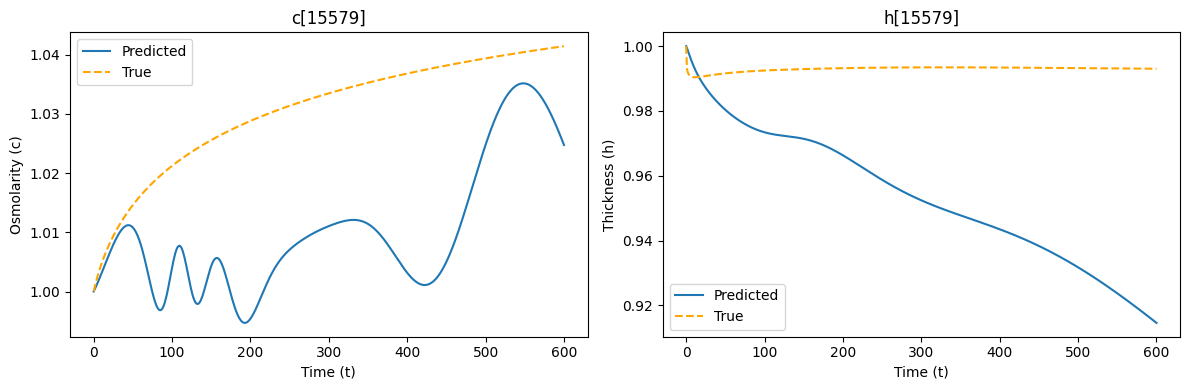

True PCA coefficients for c: [-5.25385123e+01  5.56426170e+00 -1.70675158e+00  2.62466720e-01
 -5.00035700e-01  7.77211719e-02  2.82052409e-01 -1.32627741e-01
  1.36097971e-01 -2.31586063e-02 -3.84904983e-02 -4.67217443e-03
 -1.15527385e-02  4.14457507e-03]
Predicted PCA coefficients for c: [[-5.3039318e+01  5.3986297e+00 -1.7095528e+00  1.5849657e-01
  -4.3417907e-01  1.6326895e-01  3.1968188e-01 -1.2783718e-01
   1.8017903e-01  1.1512458e-02 -9.7129896e-02  3.7761252e-02
   4.8774350e-03  3.5773680e-02]]
True PCA coefficients for h: [14.97677224 -2.84304171  1.32585823 -0.38580585  0.11453901 -0.10152712
  0.03802717]
Predicted PCA coefficients for h: [[ 1.4015469e+01 -2.4090908e+00  1.0902095e+00 -2.6299894e-01
   9.1709003e-02 -5.4210693e-02 -3.7321171e-03]]


In [35]:
n = np.random.choice(len(data_I_glob))  # Randomly select an index for testing
true_pca_c = y_test_c_glob_pca[n]
pred_pca_c = model_c.predict(X_test_glob_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(pred_pca_c)

true_pca_h = y_test_h_glob_pca[n]
pred_pca_h = model_h.predict(X_test_glob_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(pred_pca_h)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(y_test_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(y_test_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

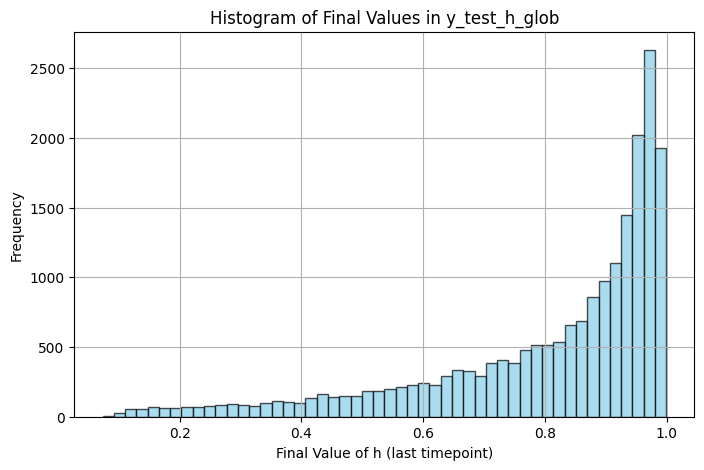

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(y_test_h_glob[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

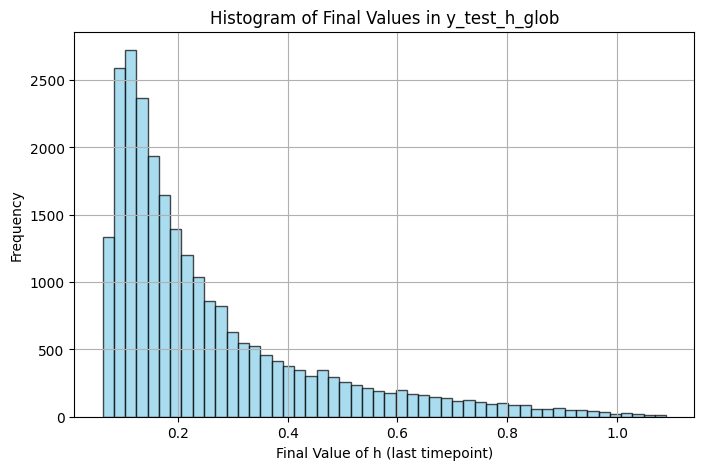

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(data_h_test[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c.steps, np.log10(losshistory_c.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c.steps, np.log10(losshistory_c.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'losshistory_c' is not defined

<Figure size 800x500 with 0 Axes>

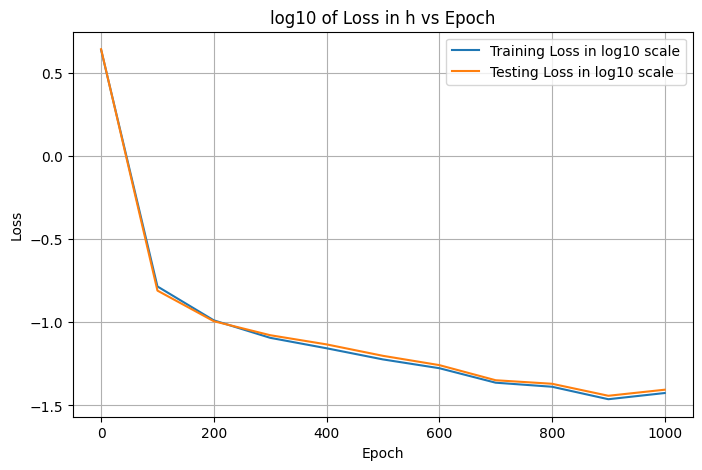

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h.steps, np.log10(losshistory_h.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_h.steps, np.log10(losshistory_h.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in h vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Testing the model on experimental data

In [39]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [40]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [41]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [42]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [43]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [44]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

datastore.close()  # Close the read-only handle

Global RMSE for model_c: 0.7537471614969805
Global RMSE for model_h: 0.09102406426102277


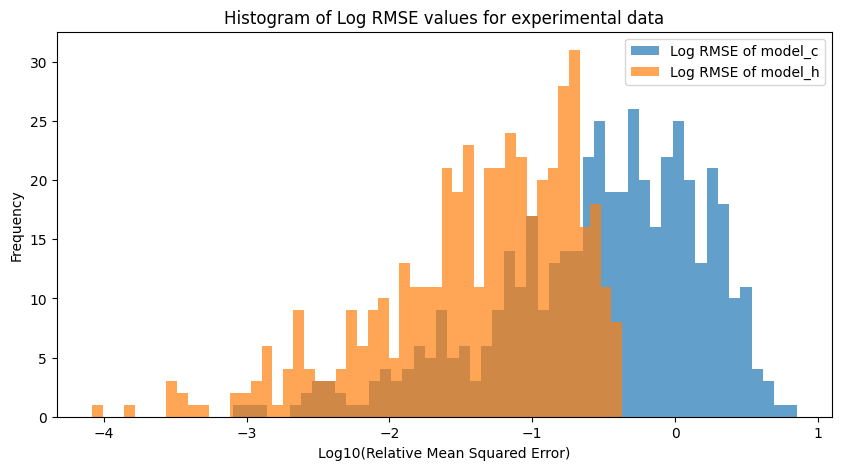

In [45]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

X_test_calculated_pca = pca_i.transform(X_test_expr)
y_test_c_calculated_pca = pca_c.transform(y_test_c_calculated)
y_test_h_calculated_pca = pca_h.transform(y_test_h_calculated)

# Use trained models to make predictions
predictions_c_calculated_pca = model_c.predict(X_test_calculated_pca)
predictions_h_calculated_pca = model_h.predict(X_test_calculated_pca)

predictions_c_calculated = pca_c.inverse_transform(predictions_c_calculated_pca)
predictions_h_calculated = pca_h.inverse_transform(predictions_h_calculated_pca)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_calculated = np.mean((predictions_c_calculated - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1)
rmse_h_calculated = np.mean((predictions_h_calculated - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1)

print("Global RMSE for model_c:", np.mean(rmse_c_calculated))
print("Global RMSE for model_h:", np.mean(rmse_h_calculated))
# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_calculated), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_calculated), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data')
plt.legend()
plt.show()

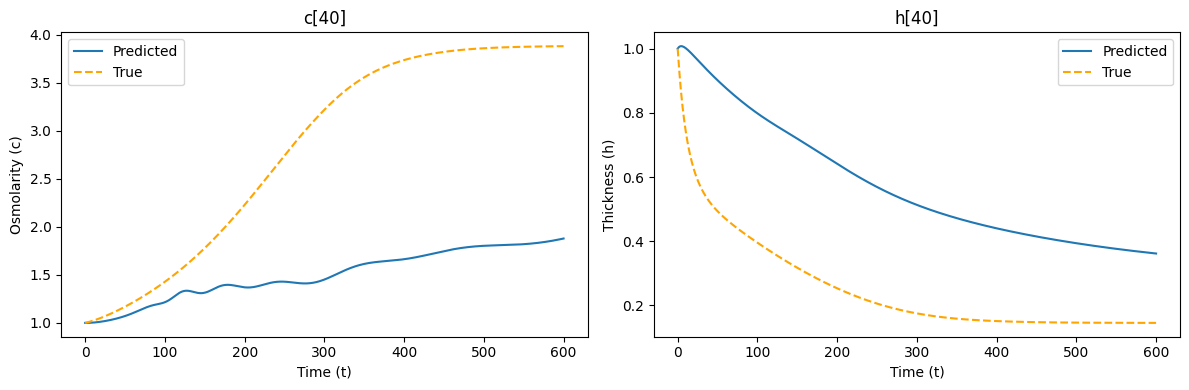

True PCA coefficients for c: [-5.33127285e+01  5.54564864e+00 -1.79173185e+00  2.21658620e-01
 -5.45828134e-01  1.16897005e-01  3.28756842e-01 -1.77027203e-01
  1.69615673e-01 -4.20341542e-02 -5.47885087e-02 -1.80511677e-02
 -2.60414812e-02 -7.49378637e-03]
Predicted PCA coefficients for c: [[-3.98718872e+01  3.53993654e+00  6.65126517e-02  5.85652351e-01
  -3.89230728e-01 -1.53310329e-01 -4.34685498e-03 -1.47775292e-01
   9.34587419e-02  4.69211340e-02 -1.21731356e-01  7.80190676e-02
   1.26199618e-01 -3.14433247e-01]]
True PCA coefficients for h: [ 5.70251617  1.27373488 -0.47437243  0.28466829 -0.15226951  0.06551056
 -0.04820925]
Predicted PCA coefficients for h: [[ 4.706495    1.3824648  -0.0960819   0.04124004  0.06898914 -0.01252024
  -0.05059438]]


In [46]:
n = np.random.choice(len(X_test_expr))  # Randomly select an index for testing
true_pca_c = y_test_c_calculated_pca[n]
pred_pca_c = model_c.predict(X_test_calculated_pca[n].reshape(1, -1))
pred_c = pca_c.inverse_transform(pred_pca_c)

true_pca_h = y_test_h_calculated_pca[n]
pred_pca_h = model_h.predict(X_test_calculated_pca[n].reshape(1, -1))
pred_h = pca_h.inverse_transform(pred_pca_h)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(pred_c.T)
axs[0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0].set_title('c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')
axs[0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1].plot(pred_h.T)
axs[1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1].set_title('h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')
axs[1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print("True PCA coefficients for c:", true_pca_c)
print("Predicted PCA coefficients for c:", pred_pca_c)
print("True PCA coefficients for h:", true_pca_h)
print("Predicted PCA coefficients for h:", pred_pca_h)

In [47]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated = predictions_c_calculated * f_0_experimental[:, np.newaxis]


In [48]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

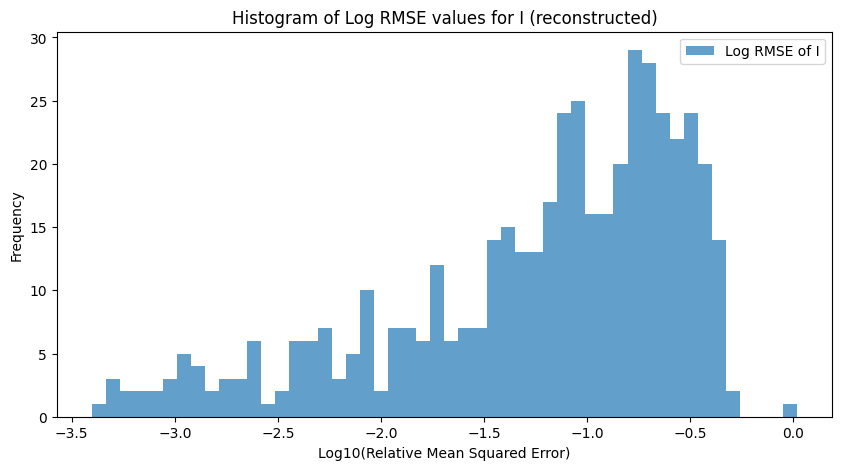

In [49]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred = 1/calculate_I(predictions_h_calculated[:,0].reshape(phi_expanded.shape), predictions_f_calculated[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred = calculate_I(predictions_h_calculated, predictions_f_calculated, phi=phi_expanded, I_0=I_0_pred)

# Compute relative MSE for each sample
rel_mse_I = np.sum((I_pred - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1)

# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_mse_I), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.show()

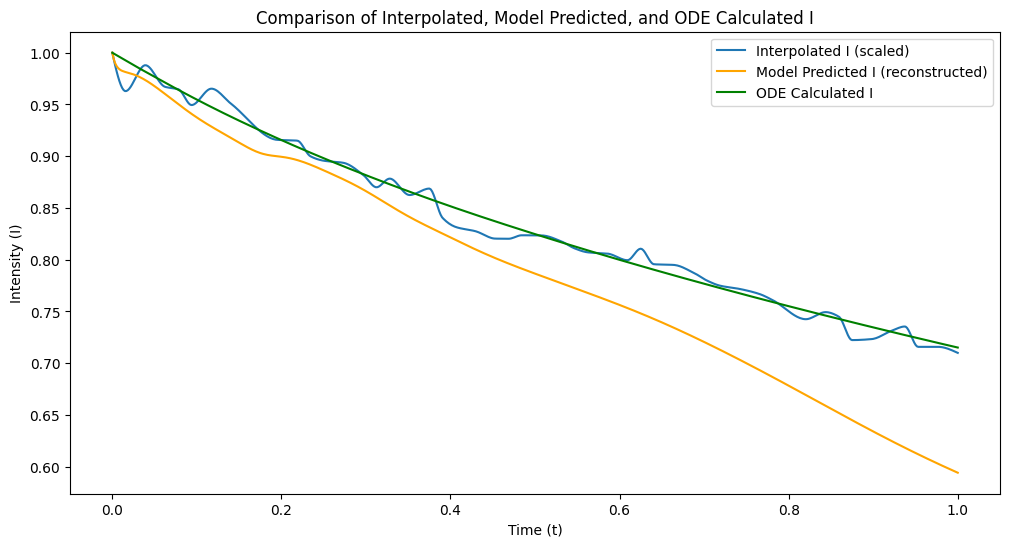

In [54]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [55]:
import os

# Path where plots will be stored
plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/h_plots"
plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/c_plots"
plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/f_plots"
plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/I_plots"
os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# Loop through all 467 samples
for idx in range(467):
    # Get data for this sample (already loaded in your variables)
    id = id_array[idx]
    t = t_scaled_interp[idx]
    I_exp = I_scaled_interp[idx]
    h_true = data_h_calculated[idx]
    c_true = data_c_caluculated[idx]
    f_true = data_f_calculated[idx]
    
    I_pred_n = I_pred[idx]
    h_pred = predictions_h_calculated[idx]
    c_pred = predictions_c_calculated[idx]
    f_pred = predictions_f_calculated[idx]
    
    I_ode = data_I_calculated[idx]
    
    fig1, ax1 = plt.subplots()
    ax1.plot(t, I_exp, label='Experimental I (scaled)')
    ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
    ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
    ax1.set_title(f'I for Sample {id}')
    ax1.set_xlabel('Time Index')
    ax1.set_ylabel('I')
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig(f"{plot_dir_I}/I_{id}.png")
    plt.close(fig1)

    fig2, ax2 = plt.subplots()
    ax2.plot(t, h_true, label='ODE calculated h')
    ax2.plot(t, h_pred, label='Model Predicted h')
    ax2.set_title(f'h for Sample {id}')
    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('h')
    ax2.legend()
    fig2.tight_layout()
    fig2.savefig(f"{plot_dir_h}/h_{id}.png")
    plt.close(fig2)
    
    fig3, ax3 = plt.subplots()
    ax3.plot(t, c_true, label='ODE calculated c')
    ax3.plot(t, c_pred, label='Model Predicted c')
    ax3.set_title(f'c for Sample {id}')
    ax3.set_xlabel('Time Index')
    ax3.set_ylabel('c')
    ax3.legend()
    fig3.tight_layout()
    fig3.savefig(f"{plot_dir_c}/c_{id}.png")
    plt.close(fig3)
    
    fig4, ax4 = plt.subplots()
    ax4.plot(t, f_true, label='ODE calculated f')
    ax4.plot(t, f_pred, label='Model Predicted f')
    ax4.set_title(f'f for Sample {id}')
    ax4.set_xlabel('Time Index')
    ax4.set_ylabel('f')
    ax4.legend()
    fig4.tight_layout()
    fig4.savefig(f"{plot_dir_f}/f_{id}.png")
    plt.close(fig4)
